In [1]:
# libraries for this homework
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tensorflow.keras.utils import get_file
import gensim.downloader as api
from gensim.models import Word2Vec

# last 4 of my SJSUid - 0670
SID4 = 670
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# set seeds
random.seed(SEED)
np.random.seed(SEED)

print("SID4: %04d" % SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)
print("HP_ID is reported only. HW2 has no HP_ID mapping.")


SID4: 0670
SEED: 670
SLICE: 670
HP_ID: 4
CLS_A: 0
CLS_B: 5
HP_ID is reported only. HW2 has no HP_ID mapping.


# Sneha Singh
## DATA 266 — Homework 2, Part 1
Embedding transfer on IMDB with Word2Vec (`word2vec-google-news-300`)


## Part 1. Embedding-based transfer learning (4 points)

I load Google News Word2Vec and copy the five word vectors as the original reference. `api.load` returns KeyedVectors, which cannot train. I build a separate Word2Vec model on the IMDB vocabulary, copy overlapping Google News vectors into it, then continue training that model on IMDB. That is transfer, not a new embedding table from scratch.

The five words can mean more than one thing. In news, `plot` can be a conspiracy and `score` can be sports. After IMDB I expect them to sit closer to movie language.


In [2]:
# assignment words and small run settings
WORDS = ["cast", "score", "plot", "screen", "review"]
TOP_K = 3
N_REVIEWS = 5000
FT_EPOCHS = 2



### 1.1 Load pretrained Word2Vec

I load the pretrained Google News Word2Vec model (`word2vec-google-news-300`). Each word is a 300-d vector. gensim caches the file after the first download.


In [3]:
# pretrained Google News vectors
w2v = api.load("word2vec-google-news-300")
print("vocab:", len(w2v.key_to_index))
print("vector size:", w2v.vector_size)

for w in WORDS:
    print(w, "in vocab:", w in w2v.key_to_index)



vocab: 3000000
vector size: 300
cast in vocab: True
score in vocab: True
plot in vocab: True
screen in vocab: True
review in vocab: True


In [4]:
# copy vectors now; train() would overwrite the same memory
original_vectors = {w: w2v[w].copy() for w in WORDS}


def neighbor_table(model, words, k=TOP_K):
    rows = []
    for w in words:
        pairs = model.most_similar(w, topn=k)
        text = "; ".join([f"{tok}={sim:.3f}" for tok, sim in pairs])
        rows.append({"word": w, "neighbors": text})
    return pd.DataFrame(rows)


before_df = neighbor_table(w2v, WORDS, TOP_K)
print("BEFORE fine-tune (Google News)")
print(before_df.to_string(index=False))

# neighbors of plot in the original space (for the t-SNE figure later)
FOCUS = "plot"
before_nn = [tok for tok, _ in w2v.most_similar(FOCUS, topn=8)]
before_nn_vecs = {tok: w2v[tok].copy() for tok in before_nn if tok in w2v.key_to_index}
print("plot neighbors before:", before_nn)



BEFORE fine-tune (Google News)
  word                                       neighbors
  cast          casts=0.722; casting=0.719; Cast=0.664
 score       scoring=0.720; scores=0.660; scored=0.638
  plot         plots=0.762; Plot=0.652; plotting=0.633
screen screens=0.773; onscreen=0.612; LCD_screen=0.560
review  reviewed=0.663; reviewing=0.661; reviews=0.638
plot neighbors before: ['plots', 'Plot', 'plotting', 'plotted', 'plotline', 'Guy_Fawkes_gunpowder', 'uncovered_Peul', 'plotters']


### 1.2 Fine-tune on IMDB review text

Stanford ACL IMDB. I shuffle with SEED, take 5000 reviews, copy Google News vectors into a Word2Vec model, then train on those reviews.


In [5]:
# 1.2a download IMDB (cached) and take 5000 reviews
imdb_tar = get_file(
    fname="aclImdb_v1.tar.gz",
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    extract=True,
)
cache = Path(imdb_tar).resolve().parent
# keras 3 extracts to aclImdb_v1_extracted/aclImdb; older keras used cache/aclImdb
candidates = [
    cache / "aclImdb_v1_extracted" / "aclImdb",
    cache / "aclImdb",
]
imdb_root = next((c for c in candidates if (c / "train" / "pos").exists()), None)
print("IMDB folder:", imdb_root)

all_files = []
for d in [imdb_root / "train" / "pos", imdb_root / "train" / "neg"]:
    all_files.extend(sorted(d.glob("*.txt")))

print("review files on disk:", len(all_files))
random.shuffle(all_files)
subset = all_files[:N_REVIEWS]
print("using:", len(subset), "reviews")


IMDB folder: /Users/snehasingh/.keras/datasets/aclImdb_v1_extracted/aclImdb
review files on disk: 25000
using: 5000 reviews


In [6]:
def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


sentences = []
for path in subset:
    tokens = tokenize(path.read_text(encoding="utf-8", errors="ignore"))
    if tokens:
        sentences.append(tokens)

print("tokenized reviews:", len(sentences))
for w in WORDS:
    n = sum(w in sent for sent in sentences)
    print(f"reviews containing '{w}':", n)



tokenized reviews: 5000
reviews containing 'cast': 672
reviews containing 'score': 178
reviews containing 'plot': 1015
reviews containing 'screen': 439
reviews containing 'review': 184


In [7]:
# 1.2c copy Google News vectors into a Word2Vec model, then train on IMDB
# api.load gives KeyedVectors (lookup only). Word2Vec is what can train.
# Do not use ft.wv[word] = vec — that clears vocab in gensim 4.
ft = Word2Vec(vector_size=w2v.vector_size, min_count=1, window=5, sg=1, workers=1, seed=SEED)
ft.build_vocab(sentences)
print("IMDB vocab:", len(ft.wv), "reviews:", ft.corpus_count)

n_copied = 0
for word, idx in ft.wv.key_to_index.items():
    if word in w2v.key_to_index:
        ft.wv.vectors[idx] = w2v[word]
        n_copied += 1
print("copied pretrained vectors:", n_copied, "/", len(ft.wv))

ft.wv.vectors_lockf = np.ones(len(ft.wv), dtype=np.float32)
ft.train(sentences, total_examples=ft.corpus_count, epochs=FT_EPOCHS)

after_df = neighbor_table(ft.wv, WORDS, TOP_K)
print("AFTER fine-tune (IMDB)")
print(after_df.to_string(index=False))


IMDB vocab: 38403 reviews: 5000
copied pretrained vectors: 30312 / 38403
AFTER fine-tune (IMDB)
  word                                     neighbors
  cast casting=0.726; actors=0.706; supporting=0.700
 score     scores=0.678; scoring=0.675; scored=0.618
  plot     plots=0.729; story=0.719; storyline=0.699
screen     screens=0.691; stage=0.619; theatre=0.593
review        reviews=0.784; uwe=0.694; seagal=0.687


### 1.3 Side-by-side neighbor table

Left = Google News. Right = after IMDB.


In [8]:
both = before_df.merge(after_df, on="word", suffixes=("_before", "_after"))
both = both.rename(columns={
    "neighbors_before": "before (Google News)",
    "neighbors_after": "after (IMDB)",
})
print(both.to_string(index=False))
both



  word                            before (Google News)                                  after (IMDB)
  cast          casts=0.722; casting=0.719; Cast=0.664 casting=0.726; actors=0.706; supporting=0.700
 score       scoring=0.720; scores=0.660; scored=0.638     scores=0.678; scoring=0.675; scored=0.618
  plot         plots=0.762; Plot=0.652; plotting=0.633     plots=0.729; story=0.719; storyline=0.699
screen screens=0.773; onscreen=0.612; LCD_screen=0.560     screens=0.691; stage=0.619; theatre=0.593
review  reviewed=0.663; reviewing=0.661; reviews=0.638        reviews=0.784; uwe=0.694; seagal=0.687


,word,before (Google News),after (IMDB)
0,cast,casts=0.722; casting=0.719; Cast=0.664,casting=0.726; actors=0.706; supporting=0.700
1,score,scoring=0.720; scores=0.660; scored=0.638,scores=0.678; scoring=0.675; scored=0.618
2,plot,plots=0.762; Plot=0.652; plotting=0.633,plots=0.729; story=0.719; storyline=0.699
3,screen,screens=0.773; onscreen=0.612; LCD_screen=0.560,screens=0.691; stage=0.619; theatre=0.593
4,review,reviewed=0.663; reviewing=0.661; reviews=0.638,reviews=0.784; uwe=0.694; seagal=0.687


### 1.4 Cosine between original and fine-tuned vectors

Lower cosine = the word moved more.


In [9]:
def cosine(a, b):
    return float(np.dot(a, b) / ((np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12))


shift_rows = []
for w in WORDS:
    sim = cosine(original_vectors[w], ft.wv[w])
    shift_rows.append({"word": w, "cosine_original_vs_finetuned": round(sim, 4)})

shift_df = pd.DataFrame(shift_rows)
print(shift_df.to_string(index=False))

most = shift_df.loc[shift_df["cosine_original_vs_finetuned"].idxmin(), "word"]
least = shift_df.loc[shift_df["cosine_original_vs_finetuned"].idxmax(), "word"]
print("shifted the MOST (lowest cosine):", most)
print("shifted the LEAST (highest cosine):", least)
shift_df


  word  cosine_original_vs_finetuned
  cast                        0.8019
 score                        0.8618
  plot                        0.7806
screen                        0.7885
review                        0.7306
shifted the MOST (lowest cosine): review
shifted the LEAST (highest cosine): score


,word,cosine_original_vs_finetuned
0,cast,0.8019
1,score,0.8618
2,plot,0.7806
3,screen,0.7885
4,review,0.7306


### 1.5 Figure — t-SNE for `plot`

I picked `plot` because in news it often means a conspiracy, and in reviews it means the story.

**Figure 1.** Blue = Google News. Orange = after IMDB. Gray = original neighbors of `plot`.

This is only a 2D picture. Distances here are not the same as cosine in 300-d. Table 1.4 is the real shift number.


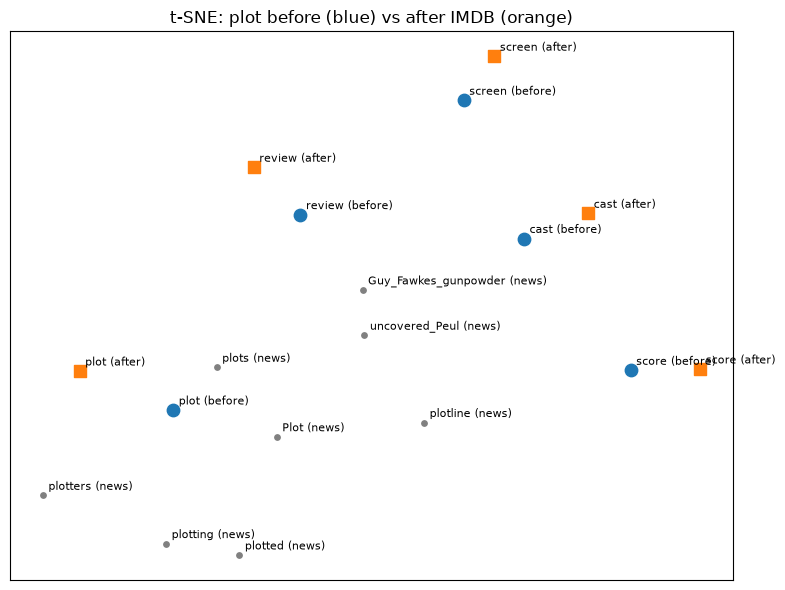

In [10]:
# plot original vs fine-tuned vectors in 2D
labels = ["plot (before)", "plot (after)"]
vecs = [original_vectors[FOCUS], ft.wv[FOCUS]]

for tok, vec in before_nn_vecs.items():
    labels.append(tok + " (news)")
    vecs.append(vec)

for w in WORDS:
    if w == FOCUS:
        continue
    labels.append(w + " (before)")
    vecs.append(original_vectors[w])
    labels.append(w + " (after)")
    vecs.append(ft.wv[w])

X = np.vstack(vecs)
n = X.shape[0]
perp = min(5, max(2, n - 1))
tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp, init="pca", learning_rate="auto")
Z = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
for i, lab in enumerate(labels):
    if "before" in lab:
        plt.scatter(Z[i, 0], Z[i, 1], c="tab:blue", marker="o", s=80)
    elif "after" in lab:
        plt.scatter(Z[i, 0], Z[i, 1], c="tab:orange", marker="s", s=80)
    else:
        plt.scatter(Z[i, 0], Z[i, 1], c="0.5", marker=".", s=60)
    plt.annotate(lab, (Z[i, 0], Z[i, 1]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.title("t-SNE: plot before (blue) vs after IMDB (orange)")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()
